<a href="https://colab.research.google.com/github/nolvertou/MachineLearning/blob/ML_Titanic_Project/MyTitanicProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project 1**: **Titanic Survival Prediction**

# **1. Project Specifications**

## Dataset Description
### Overview
The data has been split into two groups:
1.   training set (train.csv)
2.   test set (test.csv)

The **training set** should be used to build your machine learning models. For the training set, we provide the outcome (also known as the **“ground truth”**) for each passenger. Your model will be based on “features” like passengers’ gender and class. You can also use **feature engineering** to create new features.


The **test** set should be used to see how well your model performs on unseen data. *For the test set, we do not provide the ground truth for each passenger*. **It is your job to predict these outcomes.** For each passenger in the test set, **use the model you trained to predict whether or not they survived the sinking of the Titanic.**

We also include **gender_submission.csv**, a set of predictions that assume all and only female passengers survive, as an ***example of what a submission file should look like.***

# **2. Data Dictionary**


**Variable**: *Definition* {Key}


---


**survival**: *Survival* {0 = No, 1 = Yes}

**pclass**:	*Ticket class* {1 = 1st, 2 = 2nd, 3 = 3rd}

**sex**:	*Sex*

**Age**:	Age in years

**sibsp**:*# of siblings / spouses aboard the Titani*

**parch**: *# of parents / children aboard the Titanic*

**ticket**:	*Ticket number*

**fare**: 	*Passenger fare*

**cabin**:	*Cabin number*

**embarked**:	*Port of Embarkation*	{C = Cherbourg, Q = Queenstown, S = Southampton}



---


**Variable Notes**

**pclass**: A proxy for socio-economic status (SES)

**1st** = Upper

**2nd** = Middle

**3rd** = Lower

**age**: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp**: The dataset defines family relations in this way...

**Sibling** = brother, sister, stepbrother, stepsister

**Spouse** = husband, wife (mistresses and fiancés were ignored)

**parch**: The dataset defines family relations in this way...

**Parent** = mother, father

**Child** = daughter, son, stepdaughter, stepson

Some children travelled only with a nanny, therefore parch=0 for them.

hello


Step 1: Import the libraries

In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Read Train and Test Datasets

In [6]:
titanic_train = pd.read_csv('/content/train.csv')
titanic_test = pd.read_csv('/content/test.csv')

Step 3: Show a head sample from train dataset.
```Note: Head() shows the first 5 rows as default```

In [7]:
titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **3. Libraries**

In [ ]:
import pandas as pd  # Using to read datasets
import numpy as np
import matplotlib.pyplot as plt # Using to display graphs
import seaborn as sns

# **4. Read Datasets**

## 4.1 Read Train Dataset

In [8]:
titanic_train = pd.read_csv('/content/train.csv')

In [11]:
titanic_train.head() # Show a head sample from train dataset.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4.2 Read Test Dataset

In [9]:
titanic_test = pd.read_csv('/content/test.csv')

In [12]:
titanic_test.head() # Show a head sample from test dataset.

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# **5. Train Dataset Analysis**

In [14]:
titanic_train.shape # Show the shape of train dataset

(891, 12)

There are 891 rows(passengers) and 12 columns(features)

## **5.3 Survival**

In [16]:
titanic_train['Survived'].value_counts() # Show the count of survived passengers

Survived
0    549
1    342
Name: count, dtype: int64

342 passengers survived and 549 died

In [17]:
titanic_train['Survived'].value_counts().keys() # Show the keys of survived passengers

Index([0, 1], dtype='int64', name='Survived')

.keys is used to extract the categories,

eg. we have 0 and 1 for Survived Passengers feature

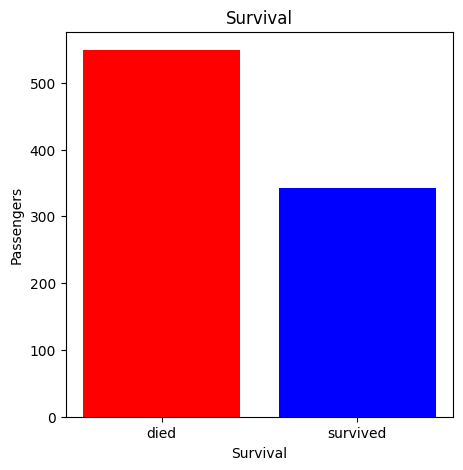

In [33]:
plt.figure(figsize=(5,5))
plt.bar(titanic_train['Survived'].value_counts().keys(), titanic_train['Survived'].value_counts(), color=['r','b'], tick_label=['died', 'survived'], )
plt.xlabel('Survival')
plt.ylabel('Passengers')
plt.title('Survival')
plt.show()

Figure 1. Survived Passengers using plt

##**5.2 Ticket class**

In [26]:
titanic_train['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

There is more people of lower class

1: Upper Class(184)

2: Middle Class (216)

3: Lower Class (491)

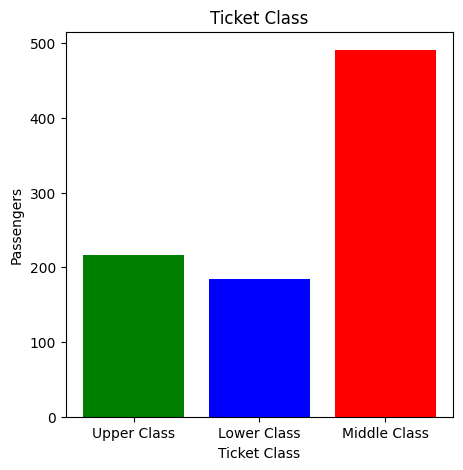

In [32]:
plt.figure(figsize=(5,5))
plt.bar(titanic_train['Pclass'].value_counts().keys(), titanic_train['Pclass'].value_counts(), color=['r','g','b'], tick_label = ['Middle Class', 'Upper Class', 'Lower Class'])
plt.xlabel('Ticket Class')
plt.ylabel('Passengers')
plt.title('Ticket Class')
plt.show()